# Importations

In [1]:
# Numerical and scientific python programming
import numpy as np

import matplotlib.pyplot as plt

# Auxiliary python functions
import time

# Local importations
from moments.bloch import (generate_pauli_basis, compute_tensor_basis, compute_subset_index_map,
                           compute_bipartite_region_upper, compute_bipartite_region_ent, compute_bipartite_region_lower)
from moments.optimization import OptimizationResult, opt_moment_preserving_ent

# Saving
from moments.saving import get_experiment_paths

data_dir, _ = get_experiment_paths(__vsc_ipynb_file__)

## Analytical conditions

In general, the 3D region explored consits of a subset of $\mathbb R^3$ that satisfy certain constraints.
In particular, those are

- $x, y, z \ge 0$,
- $z \ge x + y - 1$,
- $z^2 \le 3 + x^2 + y^2 - 4xy - 4|x-y|$,
- $x = y$.

Therefore, is the intersection of a region in the first quadrant and the plane $x=y$. Since $x=y$, the inequalities become:

- $x, z \ge 0$,
- $z \ge 2x - 1$,
- $z \le \sqrt{3 - 2 x^2}$.

We can call $t$ the distance to the $z$-axis from the points in the $x=y$ plane. Thus, change the coordinates to a 2D representation where we use the intersection between the $x=y$ and $z=0$ planes as first coordinate, and $z$ as the second coordinate. Then, we would have $t = \sqrt{x^2 + y^2} = \sqrt2 x$ or $x = y = t/\sqrt2$, which transforms the inequalities as:

- $(t, z) \in [0, \sqrt2] \times [0, \sqrt3]$
- $t, z \ge 0$,
- $z \ge \sqrt2 t - 1$,
- $z^2 \le 3 - t^2$.

In [2]:
dim = [2, 2]
N = len(dim)

pauli_basis = generate_pauli_basis()
local_bases = [pauli_basis.copy()] * N
local_basis_sizes = [len(basis) for basis in local_bases]

tensor_basis = compute_tensor_basis(local_bases)
subset_index_map = compute_subset_index_map(local_basis_sizes)

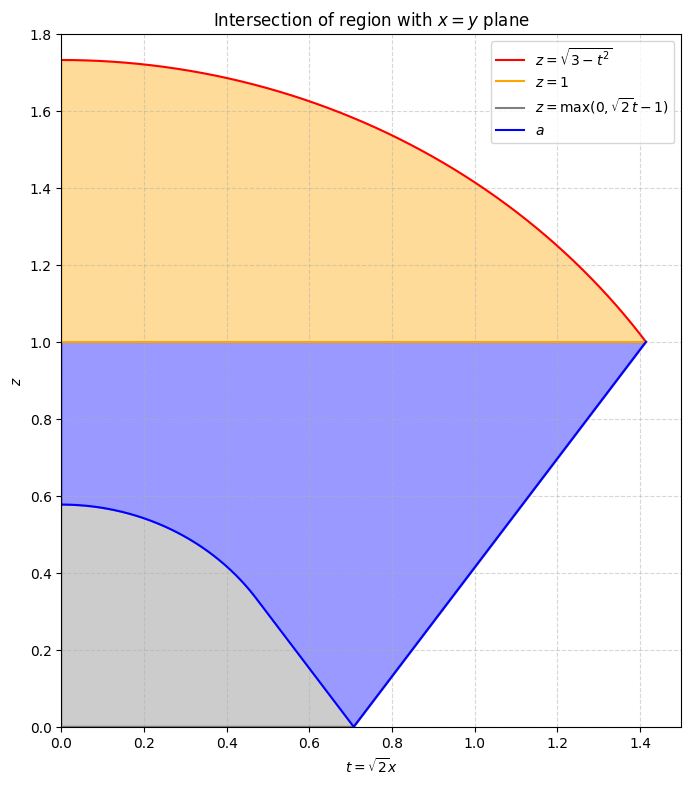

In [3]:
t = np.linspace(0, np.sqrt(2), 1000)
x = t / np.sqrt(2)

z_upper = compute_bipartite_region_upper(2, x, x)
z_ent = compute_bipartite_region_ent(2, x, x)
z_sep = np.piecewise(t, [t <= np.sqrt(2)/3, (t > np.sqrt(2)/3) & (t <= np.sqrt(2)/2), t > np.sqrt(2)/2],
                     [lambda t: np.sqrt(1/3 - t**2), lambda t: 1 - np.sqrt(2) * t, lambda t: np.sqrt(2) * t - 1])
z_lower = compute_bipartite_region_lower([2, 2], x, x)

fig, ax = plt.subplots(figsize=(8, 9))

ax.fill_between(t, z_upper, z_ent, alpha=0.4, color='orange')
ax.fill_between(t, z_ent, z_sep, alpha=0.4, color='blue')
ax.fill_between(t, z_sep, z_lower, where=(t <= np.sqrt(2)/2), alpha=0.4, color='grey')

ax.plot(t, z_upper, 'red', label=r"$z = \sqrt{3 - t^2}$")
ax.plot(t, z_ent, 'orange', label=r"$z = 1$")
ax.plot(t, z_lower, 'grey', label=r"$z = \max(0, \sqrt{2} t - 1)$")
ax.plot(t, z_sep, 'blue', label=f"$a$")



ax.set(xlabel = r'$t = \sqrt{2} x$', ylabel = r'$z$', title = 'Intersection of region with $x=y$ plane',
       xlim = (0, 1.5), ylim = (0, 1.8))
ax.grid(True, alpha=0.5, linestyle="--")
ax.legend()
plt.show()

## Moment space discretization

In [4]:
D = 200
Dt, Dz = D + 1, int(np.sqrt(3/2) * D) + 1

t = np.linspace(0, np.sqrt(2), Dt)
x = t / np.sqrt(2)
z = np.linspace(0, np.sqrt(3), Dz)

X, Z = np.meshgrid(x, z, indexing='ij')

mask_state_1 = Z >= 2*X - 1
mask_state_2 = Z**2 <= 3 - 2*X**2
mask_state = mask_state_1 & mask_state_2

indices = np.where(mask_state)
total_points = len(indices[0])
print(f"Number of points:", total_points)

sep_vals = np.full_like(X, np.nan)
sep_vals[X <= 1/3] = np.sqrt(1/3 - 2*X[X <= 1/3]**2)
sep_vals[(X > 1/3) & (X <= 1/2)] = 1 - 2*X[(X > 1/3) & (X <= 1/2)]
sep_vals[(X > 1/2)] = 2*X[(X > 1/2)] - 1

mask_ent = (Z**2 <= 3 - 2*X**2) & (Z > 1)
mask_mix = (Z <= 1) & (Z > sep_vals)
mask_sep = (Z >= 0) & (Z <= sep_vals)

Number of points: 35759


## Optimization

In [5]:
def run_succes(run_kwargs, max_attempts=5):
    result: OptimizationResult | None = None
    for _ in range(max_attempts):
        result = opt_moment_preserving_ent(**run_kwargs)
        if result.optimizer_info["result_success"]:
            return result
    return result

def run_repeat(run_kwargs, attempts=5):
    maximize = (run_kwargs["optimization"] == "maximize")
    best_result = None
    best_metric = -np.inf if maximize else np.inf

    for _ in range(attempts):
        result = opt_moment_preserving_ent(**run_kwargs)

        if (maximize and result.metric_final > best_metric) or \
           (not maximize and result.metric_final < best_metric):
            best_metric = result.metric_final
            best_result = result

    return best_result

In [ ]:
success, times = [], []
ent_max = np.full_like(X, np.nan, dtype=float)

run_kwargs = {"dim": dim, "tensor_basis": tensor_basis, "subset_index_map": subset_index_map,
              "optimization": "maximize", "metric": "partial_trace_norm", "cholesky_opt": True, "exact_jac": True}

for counter, (idx, jdx) in enumerate(zip(indices[0], indices[1]), 1):
    t0 = time.time()

    x_val = X[idx, jdx]
    z_val = Z[idx, jdx]

    Rt = {(1,): float(x_val), (2,): float(x_val), (1, 2): float(z_val)}
    run_kwargs["Rt"] = Rt
    
    if mask_ent[idx, jdx]:
        optimization_result = opt_moment_preserving_ent(**run_kwargs)

    elif mask_mix[idx, jdx]:
        optimization_result = run_repeat(run_kwargs)

    elif mask_sep[idx, jdx]:
        optimization_result = opt_moment_preserving_ent(**run_kwargs)
    
    else:
        continue
    
    ent_max[idx, jdx] = optimization_result.metric_final
    success.append(optimization_result.optimizer_info["result_success"])

    tf = time.time()
    times.append(tf-t0)
    
    percent_complete = (counter / total_points) * 100
    print(f"\rProgress: {percent_complete:.2f}% ({counter}/{total_points}) | Time for this point: {tf-t0:.3f} s", end="", flush=True)

print(f"\n\nDone!")
print(f"Successful optimizations: {sum(success)}/{total_points} | Percentage: {sum(success)*100/total_points:.2f} %")
print(f"Total time: {sum(times)/60:.2f} min | Average time per point: {sum(times)/total_points:.3f} s", )

In [ ]:
success, times = [], []
ent_min = np.full_like(X, np.nan, dtype=float)

run_kwargs = {"dim": dim, "tensor_basis": tensor_basis, "subset_index_map": subset_index_map,
              "optimization": "minimize", "metric": "partial_trace_norm", "cholesky_opt": True, "exact_jac": True}

for counter, (idx, jdx) in enumerate(zip(indices[0], indices[1]), 1):
    t0 = time.time()

    x_val = X[idx, jdx]
    z_val = Z[idx, jdx]

    Rt = {(1,): float(x_val), (2,): float(x_val), (1, 2): float(z_val)}
    run_kwargs["Rt"] = Rt

    optimization_result = opt_moment_preserving_ent(**run_kwargs)
    
    ent_min[idx, jdx] = optimization_result.metric_final
    success.append(optimization_result.optimizer_info["result_success"])

    tf = time.time()

    times.append(tf-t0)
    
    percent_complete = (counter / total_points) * 100
    print(f"\rProgress: {percent_complete:.2f}% ({counter}/{total_points}) | Time for this point: {tf-t0:.3f} s", end="", flush=True)

print(f"\n\nDone!")
print(f"Successful optimizations: {sum(success)}/{total_points} | Percentage: {sum(success)*100/total_points:.2f} %")
print(f"Total time: {sum(times)/60:.2f} min | Average time per point: {sum(times)/total_points:.3f} s", )

# Repeat inestability

In [ ]:
ent_repeat = (np.abs(ent_max - 1) < 1e-10) & mask_mix
indices = np.where(ent_repeat)
total_points = len(indices[0])
print(f"Number of points:", total_points)

fig, ax = plt.subplots(figsize=(6, 8), constrained_layout=True)

Dt, Dz = ent_max.shape
t = np.linspace(0, np.sqrt(2), Dt)
x = t / np.sqrt(2)
z = np.linspace(0, np.sqrt(3), Dz)

X, Z = np.meshgrid(x, z, indexing='ij')

mesh = ax.pcolormesh(np.sqrt(2) * X, Z, ent_repeat, shading='auto', cmap='viridis', vmin=0, vmax=1)

z_upper = compute_bipartite_region_upper(2, x, x)
z_ent = compute_bipartite_region_ent(2, x, x)
z_sep = np.piecewise(t, [t <= np.sqrt(2)/3, (t > np.sqrt(2)/3) & (t <= np.sqrt(2)/2), t > np.sqrt(2)/2],
                     [lambda t: np.sqrt(1/3 - t**2), lambda t: 1 - np.sqrt(2) * t, lambda t: np.sqrt(2) * t - 1])
z_lower = compute_bipartite_region_lower([2, 2], x, x)

for i in range(3):
    ax.set(xlabel = r"$\sqrt{2} || r_1 || = \sqrt{2} || r_2 ||$", ylabel = r"$||r_{1, 2}||$", xlim = (0, 1.5), ylim = (0, 2),
                 xticks=np.arange(0, 1.6, 0.5), yticks=np.arange(0, 2.1, 0.5))
    ax.plot(t, z_upper, 'red', linewidth=2, label='Upper bound')
    ax.plot(t, z_ent, 'orange', linewidth=2, label='Entangled')
    ax.plot(t, z_lower, 'grey', linewidth=2, label='Lower bound')
    ax.plot(t, z_sep, 'blue', linewidth=2, label='Separable')

cbar = fig.colorbar(mesh, ax=ax, label=r'$\mathcal{N}$', pad=0.02, aspect=40, shrink=1)
cbar.set_ticks(list(np.linspace(0, 1, 6)))
plt.show()

In [ ]:
run_kwargs = {"dim": dim, "tensor_basis": tensor_basis, "subset_index_map": subset_index_map,
              "optimization": "maximize", "metric": "partial_trace_norm", "cholesky_opt": True, "exact_jac": True}

times = []
for counter, (idx, jdx) in enumerate(zip(indices[0], indices[1]), 1):
    t0 = time.time()

    x_val = X[idx, jdx]
    z_val = Z[idx, jdx]

    Rt = {(1,): float(x_val), (2,): float(x_val), (1, 2): float(z_val)}
    run_kwargs["Rt"] = Rt
    
    optimization_result = run_repeat(run_kwargs, attempts=1)
    
    if optimization_result.metric_final > ent_max[idx, jdx]:
        ent_max[idx, jdx] = optimization_result.metric_final

    tf = time.time()
    times.append(tf-t0)
    
    percent_complete = (counter / total_points) * 100
    print(f"\rProgress: {percent_complete:.2f}% ({counter}/{total_points}) | Time for this point: {tf-t0:.3f} s", end="", flush=True)

print(f"\n\nDone!")
print(f"Total time: {sum(times)/60:.2f} min | Average time per point: {sum(times)/total_points:.3f} s", )

# Repeat for homogeneity

In [ ]:
run_kwargs = {"dim": dim, "tensor_basis": tensor_basis, "subset_index_map": subset_index_map,
              "optimization": "maximize", "metric": "partial_trace_norm", "cholesky_opt": True, "exact_jac": True}

times = []
for counter, (idx, jdx) in enumerate(zip(indices[0], indices[1]), 1):
    t0 = time.time()

    x_val = X[idx, jdx]
    z_val = Z[idx, jdx]

    Rt = {(1,): float(x_val), (2,): float(x_val), (1, 2): float(z_val)}
    run_kwargs["Rt"] = Rt
    
    optimization_result = run_repeat(run_kwargs, attempts=5)
    
    if optimization_result.metric_final > ent_max[idx, jdx]:
        ent_max[idx, jdx] = optimization_result.metric_final

    tf = time.time()
    times.append(tf-t0)
    
    percent_complete = (counter / total_points) * 100
    print(f"\rProgress: {percent_complete:.2f}% ({counter}/{total_points}) | Time for this point: {tf-t0:.3f} s", end="", flush=True)

print(f"\n\nDone!")
print(f"Total time: {sum(times)/60:.2f} min | Average time per point: {sum(times)/total_points:.3f} s", )

In [12]:
run_kwargs = {"dim": dim, "tensor_basis": tensor_basis, "subset_index_map": subset_index_map,
              "optimization": "minimize", "metric": "partial_trace_norm", "cholesky_opt": True, "exact_jac": True}

times = []
for counter, (idx, jdx) in enumerate(zip(indices[0], indices[1]), 1):
    t0 = time.time()

    x_val = X[idx, jdx]
    z_val = Z[idx, jdx]

    Rt = {(1,): float(x_val), (2,): float(x_val), (1, 2): float(z_val)}
    run_kwargs["Rt"] = Rt
    
    optimization_result = run_repeat(run_kwargs, attempts=5)
    
    if optimization_result.metric_final < ent_min[idx, jdx]:
        ent_min[idx, jdx] = optimization_result.metric_final

    tf = time.time()
    times.append(tf-t0)
    
    percent_complete = (counter / total_points) * 100
    print(f"\rProgress: {percent_complete:.2f}% ({counter}/{total_points}) | Time for this point: {tf-t0:.3f} s", end="", flush=True)

print(f"\n\nDone!")
print(f"Total time: {sum(times)/60:.2f} min | Average time per point: {sum(times)/total_points:.3f} s", )

Progress: 100.00% (35759/35759) | Time for this point: 0.059 s

Done!
Total time: 46.33 min | Average time per point: 0.078 s


# Save and load data

## Load

In [3]:
ent = np.load(data_dir / "trace_norm_exact.npz")

ent_max = ent["max"]
ent_min = ent["min"]

## Save

In [14]:
np.savez(data_dir / "trace_norm_exact.npz",
         max=ent_max,
         min=ent_min)

## Represent

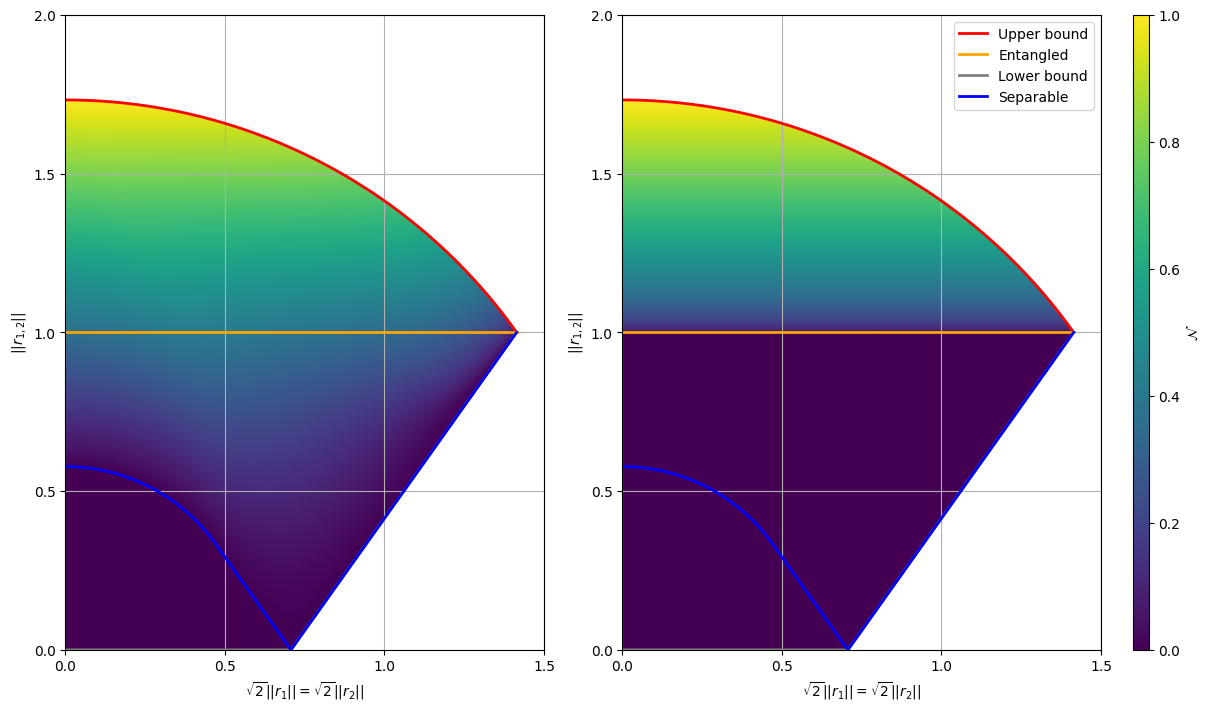

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 7), constrained_layout=True)

Dt, Dz = ent_max.shape
t = np.linspace(0, np.sqrt(2), Dt)
x = t / np.sqrt(2)
z = np.linspace(0, np.sqrt(3), Dz)

X, Z = np.meshgrid(x, z, indexing='ij')

mesh0 = ax[0].pcolormesh(np.sqrt(2) * X, Z, (ent_max - 1), shading='auto', cmap='viridis', vmin=0, vmax=1)
mesh1 = ax[1].pcolormesh(np.sqrt(2) * X, Z, (ent_min - 1), shading='auto', cmap='viridis', vmin=0, vmax=1)

z_upper = compute_bipartite_region_upper(2, x, x)
z_ent = compute_bipartite_region_ent(2, x, x)
z_sep = np.piecewise(t, [t <= np.sqrt(2)/3, (t > np.sqrt(2)/3) & (t <= np.sqrt(2)/2), t > np.sqrt(2)/2],
                     [lambda t: np.sqrt(1/3 - t**2), lambda t: 1 - np.sqrt(2) * t, lambda t: np.sqrt(2) * t - 1])
z_lower = compute_bipartite_region_lower([2, 2], x, x)

for i in range(2):
    ax[i].set(xlabel = r"$\sqrt{2} || r_1 || = \sqrt{2} || r_2 ||$", ylabel = r"$||r_{1, 2}||$", xlim = (0, 1.5), ylim = (0, 2),
                 xticks=np.arange(0, 1.6, 0.5), yticks=np.arange(0, 2.1, 0.5))
    ax[i].plot(t, z_upper, 'red', linewidth=2, label='Upper bound')
    ax[i].plot(t, z_ent, 'orange', linewidth=2, label='Entangled')
    ax[i].plot(t, z_lower, 'grey', linewidth=2, label='Lower bound')
    ax[i].plot(t, z_sep, 'blue', linewidth=2, label='Separable')
    ax[i].grid(True)

cbar = fig.colorbar(mesh0, ax=ax.ravel().tolist(), label=r'$\mathcal{N}$', pad=0.02, aspect=40, shrink=1)
cbar.set_ticks(list(np.linspace(0, 1, 6)))

ax[1].legend(loc='upper right')

plt.show()